# Clustering Track — Airplane Customer Satisfaction Segmentation

**Dataset:** Airplane Customer Satisfaction (`data/raw/airplane customer satisfaction.csv` → processed artifacts in `data/processed/clustering/`)
**Scope:** Merged end-to-end unsupervised pipeline — **(I) preprocessing & EDA**, **(II) clustering modelling**, **(III) evaluation & visualisation**
**Algorithm:** K-Means (`k` selected from a four-criterion sweep)
**Evaluation Metrics:** Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Index (+ inertia)
**Random State:** 42 (enforced throughout for complete reproducibility)
**Output Directory:** `results/clustering/`

> This notebook merges the previously separate `clustering_preprocessing.ipynb` and `clustering.ipynb` into a single
> self-contained pipeline, mirroring the structure of the Classification (`src/classification/classification.ipynb`)
> and Regression (`src/regression/regression1.ipynb`) tracks.
>
> The clustering family is **extensible**: every algorithm is scored through the shared
> `evaluate_clustering()` benchmark helper (Section 13), so an additional algorithm (Agglomerative, DBSCAN, Gaussian
> Mixture, …) only needs to produce a label vector to receive the full metric + visualisation treatment.

### Notebook Map

| Part | Sections | Contents |
|---|---|---|
| **I — Preprocessing & EDA** | 1 – 11 | Environment, raw audit, data-quality audit, feature typing, EDA (6 figures, each with inference & commentary), cleaning, skewness/outlier treatment, one-hot encoding, scaling, validation, artifact export |
| **II — Clustering Modelling** | 12 – 16 | Artifact re-load & verification, metric infrastructure, K-Means `k = 2…10` sweep, model-selection curves, optimal-`k` decision |
| **III — Evaluation & Visualisation** | 17 – 21 | Final model & cluster distribution, cluster profiling, post-hoc satisfaction analysis, PCA-reduced 2D scatter, t-SNE embedding, benchmark export |

### How to Run

The notebook resolves the repository root automatically, so it executes either from `src/clustering/`
(the convention used by the Regression track) or from the repository root:

```bash
python -m jupyter nbconvert --to notebook --execute --inplace src/clustering/clustering.ipynb
```


---
## 1. Environment Setup & Library Imports

We import the scientific-computing, preprocessing, clustering and visualisation libraries, fix the global random seed
for complete reproducibility, and configure the output directories required by the repository architecture.

Paths are resolved dynamically against the repository root so the notebook is robust to the working directory it is
launched from.

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering, dimensionality reduction & validation metrics (Parts II - III)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Visual styling (consistent with the Classification track)
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 10
pd.set_option("display.max_columns", 40)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


def _resolve_repo_root():
    """Locate the repository root so the notebook runs from src/clustering/ or from the root."""
    probe = os.path.join("data", "raw", "airplane customer satisfaction.csv")
    candidates = [
        os.path.join("..", ".."),        # executed from src/clustering/
        ".",                             # executed from the repository root
        os.path.join("src", "clustering"),
        os.path.join("..", "..", ".."),
    ]
    for base in candidates:
        if os.path.exists(os.path.join(base, probe)):
            return os.path.abspath(base)
    raise FileNotFoundError(
        "Could not locate 'data/raw/airplane customer satisfaction.csv'. "
        "Run the notebook from 'src/clustering/' or from the repository root."
    )


REPO_ROOT = _resolve_repo_root()
RAW_DATA_PATH = os.path.join(REPO_ROOT, "data", "raw", "airplane customer satisfaction.csv")
PROCESSED_DIR = os.path.join(REPO_ROOT, "data", "processed", "clustering")
RESULTS_DIR = os.path.join(REPO_ROOT, "results", "clustering")
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

X_CSV_PATH = os.path.join(PROCESSED_DIR, "X.csv")
LABEL_CSV_PATH = os.path.join(PROCESSED_DIR, "satisfaction.csv")

print("Libraries imported successfully.")
print(f"Random state        : {RANDOM_STATE} (enforced throughout)")
print(f"Repository root     : {REPO_ROOT}")
print(f"Raw dataset         : {RAW_DATA_PATH}")
print(f"Processed artifacts : {PROCESSED_DIR}")
print(f"Figures & reports   : {RESULTS_DIR}")

Libraries imported successfully.
Random state        : 42 (enforced throughout)
Repository root     : D:\Studies\projects\Machine-Learning-CaseStudy
Raw dataset         : D:\Studies\projects\Machine-Learning-CaseStudy\data\raw\airplane customer satisfaction.csv
Processed artifacts : D:\Studies\projects\Machine-Learning-CaseStudy\data\processed\clustering
Figures & reports   : D:\Studies\projects\Machine-Learning-CaseStudy\results\clustering


---
## 2. Section A — Dataset Loading & Raw Audit

The pipeline begins with a full audit of the raw file: shape, memory footprint, column dtypes, a preview of the records
and descriptive statistics. This establishes what the data actually contains *before* any transformation is applied —
an audit trail that later preprocessing decisions are justified against.

In [2]:
df_raw = pd.read_csv(RAW_DATA_PATH)

print("=== SECTION 2: RAW DATASET AUDIT ===")
print(f"Shape        : {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"Memory usage : {df_raw.memory_usage(deep=True).sum() / 1024**2:,.1f} MB")

print("\nFirst 5 rows:")
display(df_raw.head())

print("\nColumn dtypes:")
print(df_raw.dtypes.to_string())

print("\nDescriptive statistics (all columns):")
display(df_raw.describe(include="all").T)

=== SECTION 2: RAW DATASET AUDIT ===
Shape        : 103,904 rows x 25 columns


Memory usage : 45.8 MB

First 5 rows:


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0.0,satisfied



Column dtypes:
Unnamed: 0                             int64
id                                     int64
Gender                                   str
Customer Type                            str
Age                                    int64
Type of Travel                           str
Class                                    str
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                            

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,103904.0,NaN,NaN,NaN,51951.5,29994.645522,0.0,25975.75,51951.5,77927.25,103903.0
id,103904.0,NaN,NaN,NaN,64924.210502,37463.812252,1.0,32533.75,64856.5,97368.25,129880.0
Gender,103904,2,Female,52727,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Type,103904,2,Loyal Customer,84923,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,103904.0,NaN,NaN,NaN,39.379706,15.114964,7.0,27.0,40.0,51.0,85.0
Type of Travel,103904,2,Business travel,71655,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Class,103904,3,Business,49665,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Flight Distance,103904.0,NaN,NaN,NaN,1189.448375,997.147281,31.0,414.0,843.0,1743.0,4983.0
Inflight wifi service,103904.0,NaN,NaN,NaN,2.729683,1.327829,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,103904.0,NaN,NaN,NaN,3.060296,1.525075,0.0,2.0,3.0,4.0,5.0


### Loading Audit — Inference, Insight & Commentary

**Inference.** The raw file holds **103,904 passenger records** across **25 columns** — 19 integer, 5 string and 1
float — consuming roughly **46 MB** in memory (deep measurement, including the string payload). `Unnamed: 0` is an exported row index and `id` is a surrogate passenger key;
neither encodes behaviour. Sixteen of the 25 columns are bounded 0–5 survey ratings, four are unbounded continuous
measurements and four are nominal descriptors of the traveller or the itinerary.

**Insight.** The dataset mixes three fundamentally different measurement scales in one table: bounded ordinal ratings
(0–5), unbounded continuous quantities (`Flight Distance` 31–4,983; delays up to 1,592 minutes) and nominal categories.
Under a raw Euclidean distance this is a serious problem — a single 1,500-minute delay would contribute ~2.25 million to
squared distance while the entire passenger-satisfaction survey contributes at most a few hundred. Distance-based
clustering on unscaled data would therefore segment *flight delays*, not *customers*.

**Commentary.** Two consequences drive the rest of Part I: (i) nominal columns must be encoded, and (ii) **all** features
must be standardised before any centroid- or distance-based algorithm is fitted. The audit also confirms the dataset is
a binary-satisfaction survey, so `satisfaction` is set aside as a **post-hoc validation label** rather than a feature.

---
## 3. Section B — Data Quality Audit

Next we quantify data defects: missing values, exact duplicate rows, zero-variance columns, row-unique (identifier)
columns and per-column cardinality. Any issue found here determines the cleaning strategy applied in Section 6.

=== SECTION 3: DATA QUALITY AUDIT ===
Columns containing missing values:
                          Missing Count  Missing %
Arrival Delay in Minutes            310      0.298

Total missing cells       : 310 (0.012% of all cells)
Duplicate rows            : 0
Constant (zero-variance)  : none
Row-unique (identifier)   : ['Unnamed: 0', 'id']
Columns excluding identifiers      : 23 (of which 1 is the 'satisfaction' target)
Columns to be modelled             : 22 (identifiers and target excluded)

Cardinality profile (unique values per column):
Customer Type                             2
Gender                                    2
Type of Travel                            2
satisfaction                              2
Class                                     3
Baggage handling                          5
Gate location                             6
Ease of Online booking                    6
Food and drink                            6
Online boarding                           6
Seat comfort 

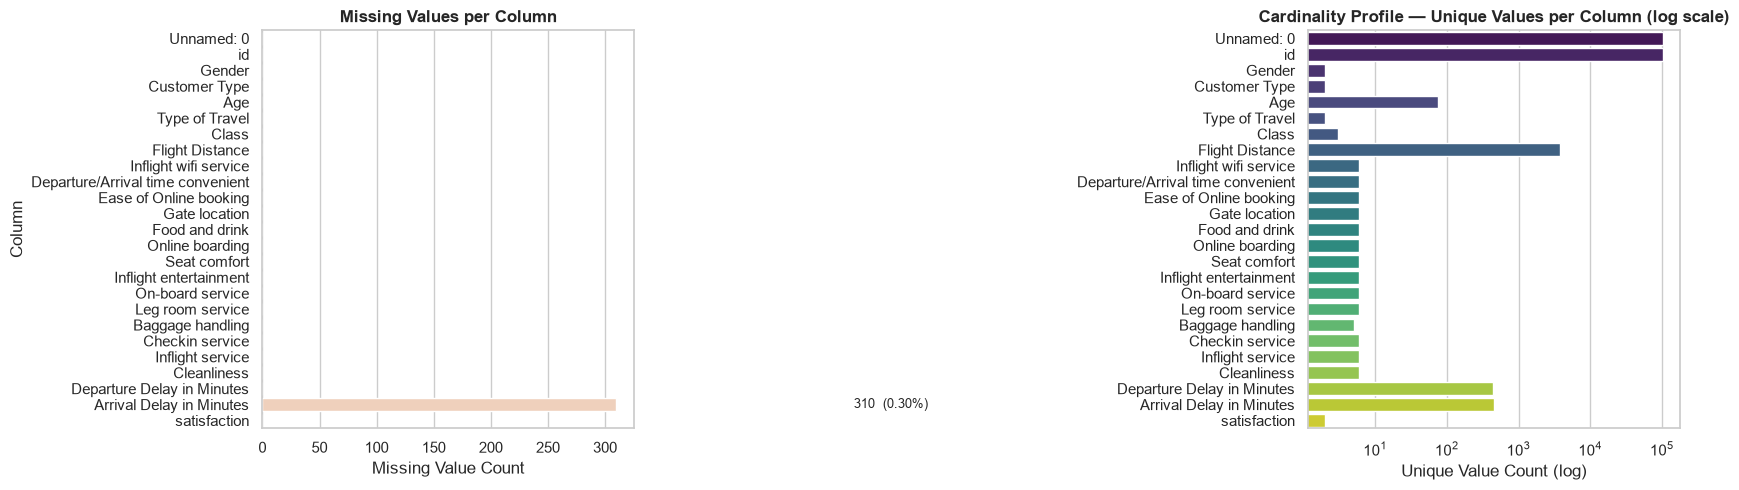

In [3]:
missing = df_raw.isnull().sum()
missing_cols = missing[missing > 0]
missing_pct = (missing_cols / len(df_raw) * 100).round(3)
duplicate_count = int(df_raw.duplicated().sum())
unique_counts = df_raw.nunique()
constant_cols = [c for c in df_raw.columns if df_raw[c].nunique() <= 1]
id_like_cols = [c for c in df_raw.columns if df_raw[c].nunique() == len(df_raw)]

print("=== SECTION 3: DATA QUALITY AUDIT ===")
if len(missing_cols) > 0:
    print("Columns containing missing values:")
    print(pd.DataFrame({"Missing Count": missing_cols, "Missing %": missing_pct}).to_string())
else:
    print("No missing values found.")

print(f"\nTotal missing cells       : {missing.sum():,} ({missing.sum() / df_raw.size * 100:.3f}% of all cells)")
print(f"Duplicate rows            : {duplicate_count}")
print(f"Constant (zero-variance)  : {constant_cols if constant_cols else 'none'}")
print(f"Row-unique (identifier)   : {id_like_cols}")
print(f"Columns excluding identifiers      : {df_raw.shape[1] - len(id_like_cols)} (of which 1 is the 'satisfaction' target)")
print(f"Columns to be modelled             : {df_raw.shape[1] - len(id_like_cols) - 1} (identifiers and target excluded)")

print("\nCardinality profile (unique values per column):")
print(unique_counts.sort_values().to_string())

# --- Audit visualisation: missing-value profile + cardinality profile ---
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

sns.barplot(
    x=missing.values, y=missing.index, hue=missing.index,
    palette="rocket", legend=False, ax=axes[0]
)
axes[0].set_title("Missing Values per Column", fontweight="bold")
axes[0].set_xlabel("Missing Value Count")
axes[0].set_ylabel("Column")
for i, v in enumerate(missing.values):
    if v > 0:
        axes[0].text(v + len(df_raw) * 0.002, i, f"{v}  ({v / len(df_raw) * 100:.2f}%)", va="center", fontsize=9)

sns.barplot(
    x=unique_counts.values, y=unique_counts.index, hue=unique_counts.index,
    palette="viridis", legend=False, ax=axes[1]
)
axes[1].set_xscale("log")
axes[1].set_title("Cardinality Profile — Unique Values per Column (log scale)", fontweight="bold")
axes[1].set_xlabel("Unique Value Count (log)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "data_quality_audit.png"), dpi=300, bbox_inches="tight")
plt.show()

### Data Quality Audit — Inference, Insight & Commentary

**Inference.** Exactly one column is incomplete: `Arrival Delay in Minutes` with **310 missing cells (0.298%** of the
dataset). There are **0 duplicate rows**, **no constant/zero-variance columns**, and precisely two row-unique
identifier columns (`Unnamed: 0`, `id`) that must be dropped. Cardinality splits cleanly into four groups: binary
nominal (2 values), multi-class nominal (`Class`, 3), bounded survey ratings (5–6 values), and high-cardinality
continuums (`Flight Distance` 3,802; `Departure Delay` 446; `Arrival Delay` 455).

**Insight.** With only 0.3% of cells missing, no row can be justified as undroppable to the contrary — but dropping
rows is still unnecessary: median imputation preserves **all 103,904 customers** for segmentation while introducing
negligible distortion. Crucially, `Arrival Delay in Minutes` is missing for a *specific* operational reason (legs that
were cancelled or never departed) rather than at random, which is worth flagging: imputed delays are a conservative
lower bound on disruption for those 310 passengers.

**Commentary.** The missing values are structural rather than informative, so the imputation strategy is kept
deliberately simple and isolated in one documented step (Section 6) instead of being spread across the pipeline. The
high-cardinality continuous columns confirm that a `StandardScaler` — not a categorical encoder — is the appropriate
treatment for them.

---
## 4. Section C — Feature Type Identification & Target Exclusion

With the data audited, we (a) remove identifier columns, (b) **exclude the supervised target** `satisfaction` from the
feature space (retained separately as an optional post-hoc label), and (c) classify every remaining feature by
measurement type, since the correct encoding treatment follows from the measurement scale itself.

In [4]:
df = df_raw.copy()

# --- (a) Remove index / identifier columns: they encode row ordering, not customer behaviour ---
id_cols = ["Unnamed: 0", "id"]
dropped_id_cols = [c for c in id_cols if c in df.columns]
df = df.drop(columns=dropped_id_cols)

# --- (b) Exclude the target label from the clustering feature matrix ---
TARGET_COL = "satisfaction"
if TARGET_COL in df.columns:
    y_optional = df.pop(TARGET_COL).copy()
else:
    y_optional = None

# --- (c) Classify the remaining features by measurement type ---
nominal_categorical_cols = ["Gender", "Customer Type", "Type of Travel", "Class"]
ordinal_survey_cols = [
    "Inflight wifi service", "Departure/Arrival time convenient", "Ease of Online booking",
    "Gate location", "Food and drink", "Online boarding", "Seat comfort",
    "Inflight entertainment", "On-board service", "Leg room service",
    "Baggage handling", "Checkin service", "Inflight service", "Cleanliness",
]
continuous_num_cols = ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]

print("=== SECTION 4: FEATURE TYPE IDENTIFICATION ===")
print(f"Dropped identifier columns            : {dropped_id_cols}")
print(f"Excluded target (post-hoc label only) : '{TARGET_COL}' -> {len(y_optional):,} labels retained")
print(f"Working feature table shape           : {df.shape}")
print(f"\nNominal categorical ({len(nominal_categorical_cols):2d}) : {nominal_categorical_cols}")
print(f"Ordinal survey 0-5  ({len(ordinal_survey_cols):2d}) : {ordinal_survey_cols}")
print(f"Continuous numeric  ({len(continuous_num_cols):2d}) : {continuous_num_cols}")
print(f"\nTotal features to be modelled         : {len(nominal_categorical_cols) + len(ordinal_survey_cols) + len(continuous_num_cols)}")

=== SECTION 4: FEATURE TYPE IDENTIFICATION ===
Dropped identifier columns            : ['Unnamed: 0', 'id']
Excluded target (post-hoc label only) : 'satisfaction' -> 103,904 labels retained
Working feature table shape           : (103904, 22)

Nominal categorical ( 4) : ['Gender', 'Customer Type', 'Type of Travel', 'Class']
Ordinal survey 0-5  (14) : ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']
Continuous numeric  ( 4) : ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

Total features to be modelled         : 22


### Feature Typing — Inference, Insight & Commentary

**Inference.** After removing the two identifier columns, the 22 candidate features split into **4 nominal**
(`Gender`, `Customer Type`, `Type of Travel`, `Class`), **14 ordinal 0–5 survey ratings** and **4 continuous** numeric
variables. The 43.3% `/` 56.7% satisfaction split is retained as a label vector aligned row-for-row with the feature
table.

**Insight.** The three groups require three different treatments, and applying the wrong one is a common source of
silent clustering failure: (i) nominal variables have no order, so one-hot encoding is required — ordinal encoding
would falsely assert `Eco Plus > Eco`; (ii) the 14 ratings are *already* on a shared, interpretable 0–5 ordinal scale,
so they need no encoding at all; (iii) the 4 continuous variables have wildly different units (years, miles, minutes)
and must be standardised.

**Commentary.** `satisfaction` is explicitly **excluded** from the feature matrix. Had it been included, the clustering
would simply rediscover the supervised label (data leakage into an unsupervised task) and every downstream metric would
be inflated and meaningless. Keeping it in `y_optional` lets us perform a genuine *post-hoc* external validation in
Section 18: "do the clusters we discovered without the label happen to separate satisfied from dissatisfied
passengers?"

---
## 5. Section D — Exploratory Data Analysis (EDA)

Six diagnostic visualisations are produced, each followed by its own inference, insight and commentary:

1. **Target balance & nominal-category satisfaction profiles** — is the label degenerate, and which traveller attributes matter?
2. **Continuous feature distributions** (raw vs `log1p`) and **IQR outlier screening** — scale, skew and defect risk.
3. **The 14 ordinal service-rating distributions** split by satisfaction — the primary clustering signal.
4. **Service-rating satisfaction gaps** and the **feature correlation structure** — which dimensions discriminate, and which are redundant.

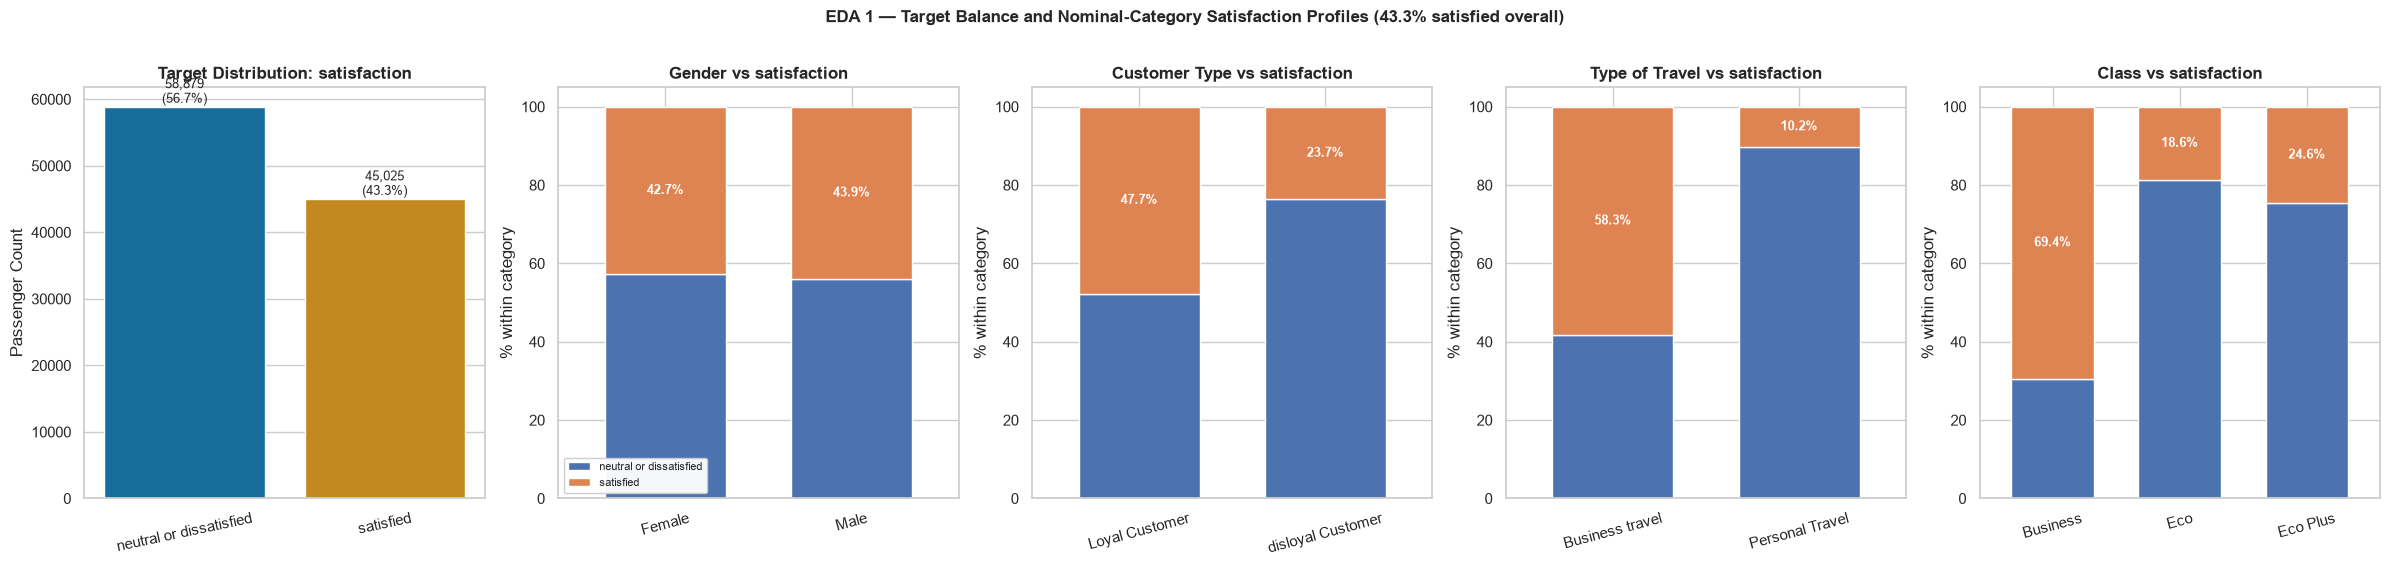

In [5]:
# =====================================================================================
# EDA FIGURE 1 - Target balance and nominal-category satisfaction profiles
# =====================================================================================
fig, axes = plt.subplots(1, 5, figsize=(24, 5.5))

# Panel 1: target class balance
sat_counts = y_optional.value_counts()
sns.barplot(x=sat_counts.index, y=sat_counts.values, hue=sat_counts.index,
            palette="colorblind", legend=False, ax=axes[0])
axes[0].set_title("Target Distribution: satisfaction", fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Passenger Count")
axes[0].tick_params(axis="x", rotation=12)
for p, v in zip(axes[0].patches, sat_counts.values):
    axes[0].annotate(f"{v:,}\n({v / len(y_optional) * 100:.1f}%)",
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom", fontsize=9)

# Panels 2-5: each nominal feature split by satisfaction (row-normalised)
for ax, col in zip(axes[1:], nominal_categorical_cols):
    ct = pd.crosstab(df[col], y_optional, normalize="index") * 100
    ct.plot(kind="bar", stacked=True, ax=ax, rot=15,
            color=["#4c72b0", "#dd8452"], legend=False, width=0.65)
    ax.set_title(f"{col} vs satisfaction", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("% within category")
    for i, cat in enumerate(ct.index):
        r = ct.loc[cat, "satisfied"]
        ax.text(i, 100 - r / 2, f"{r:.1f}%", ha="center", va="center",
                fontsize=9, color="white", fontweight="bold")

axes[1].legend(["neutral or dissatisfied", "satisfied"], loc="lower left", fontsize=8, framealpha=0.95)
fig.suptitle("EDA 1 — Target Balance and Nominal-Category Satisfaction Profiles (43.3% satisfied overall)",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "target_and_categorical_profile.png"), dpi=300, bbox_inches="tight")
plt.show()

### EDA 1 — Inference, Insight & Commentary

**Inference.** The label is mildly imbalanced: **58,879 (56.7%) neutral-or-dissatisfied** versus **45,025 (43.3%)
satisfied** — a healthy split for evaluation, with no degenerate class. Satisfaction varies enormously with itinerary
context: **Business travel 58.3% satisfied vs Personal travel 10.2%**; **Business class 69.4% vs Eco 18.6%**
(Eco Plus 24.6%); **loyal customers 47.7% vs disloyal 23.7%**. `Gender` is essentially inert (Male 44.0% vs
Female 42.7% — a 1.2 pp difference).

**Insight.** The dominant satisfaction axis in this dataset is **itinerary context (travel purpose and cabin class),
not demographics**. Personal travellers in Economy are dissatisfied roughly 4-in-5 of the time, while the proportion
inverts for Business-class business travellers. A segmentation of this population must therefore be driven mainly by
the 14 service ratings and the travel descriptors; gender contributes almost no discriminative signal and can be
expected to load near-zero on the cluster profiles.

**Commentary.** These are *marginal*, one-variable views — they show association, not structure, and they say nothing
about how attributes combine. That is precisely why clustering is applied: to expose the **joint** structure of the
23-dimensional space (e.g. whether a coherent "premium business traveller" profile emerges independently of the
one-variable rankings above). Note also the class imbalance in `Class` (Business 49,665 / Eco 46,745 / Eco Plus 7,494):
one-hot encoding will produce a rare `Class_Eco Plus` dummy, which the scaling step must handle proportionately.

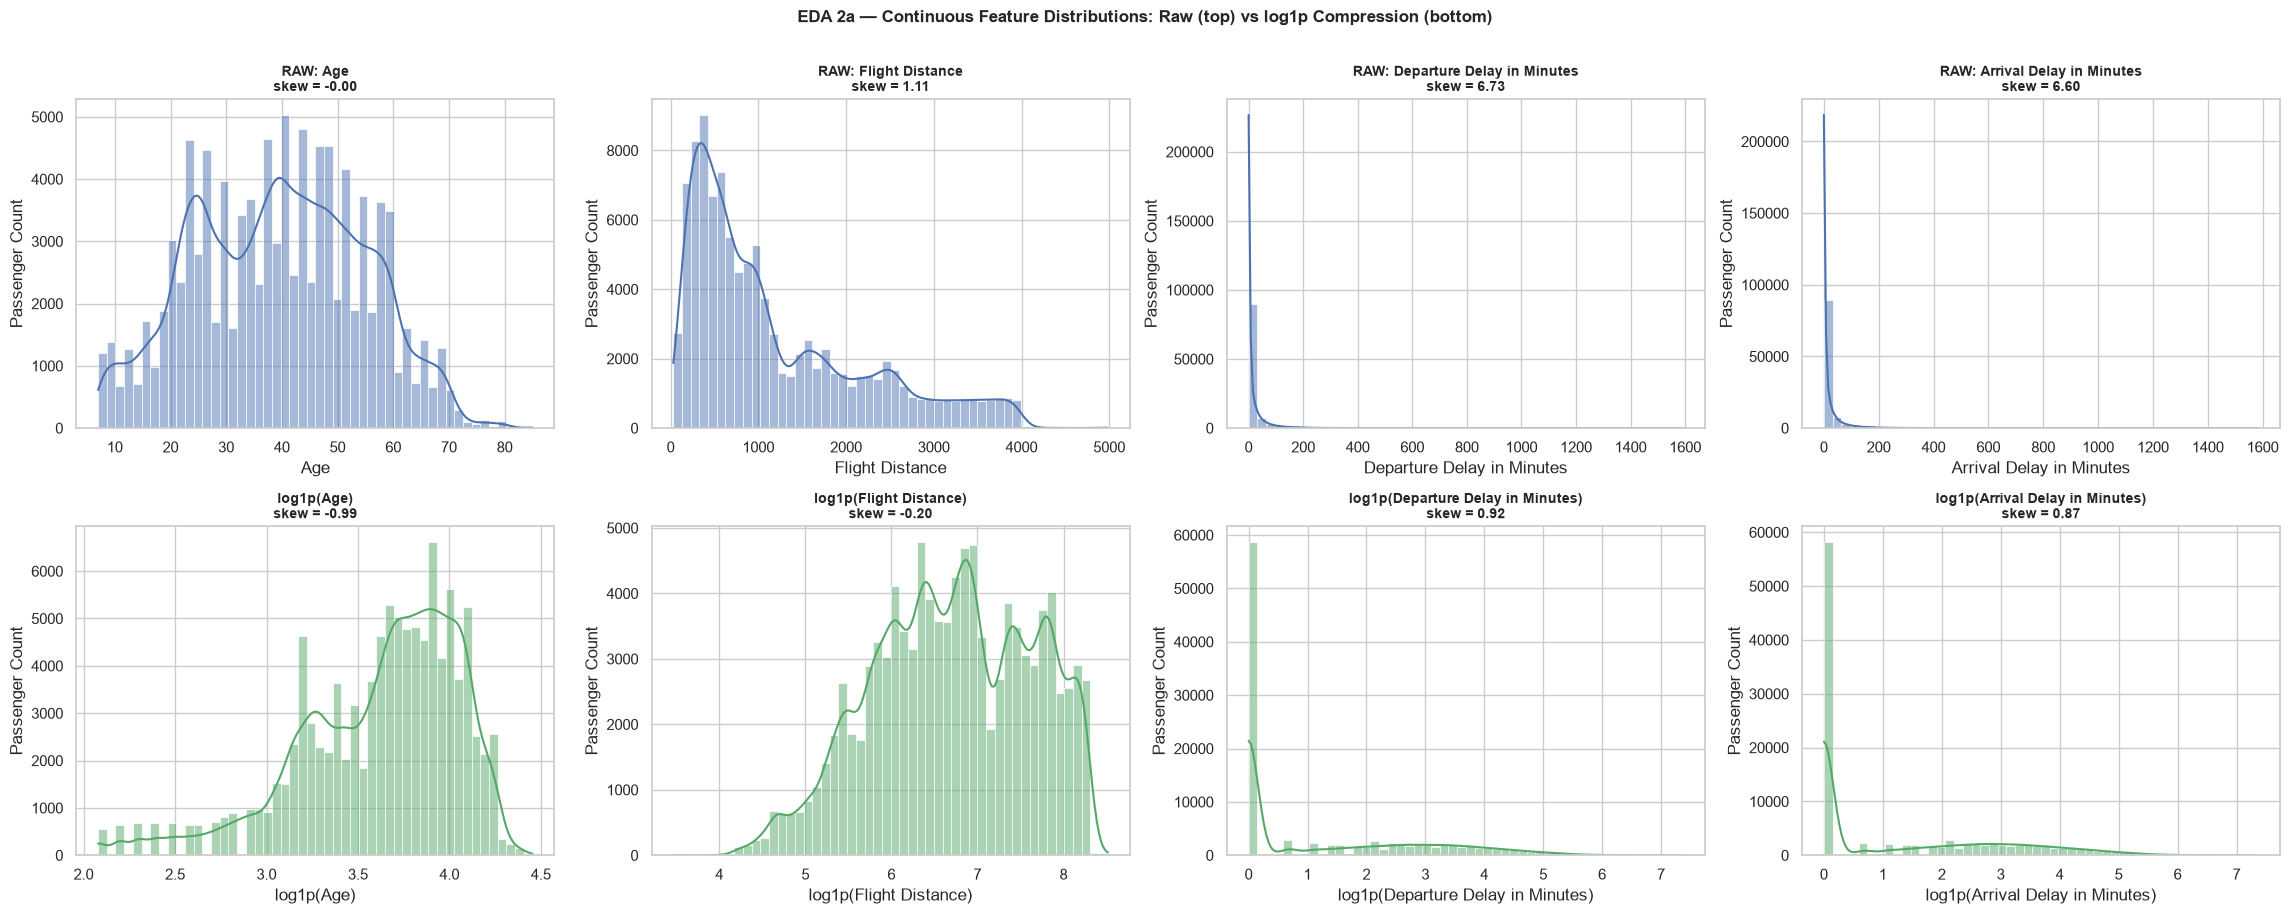

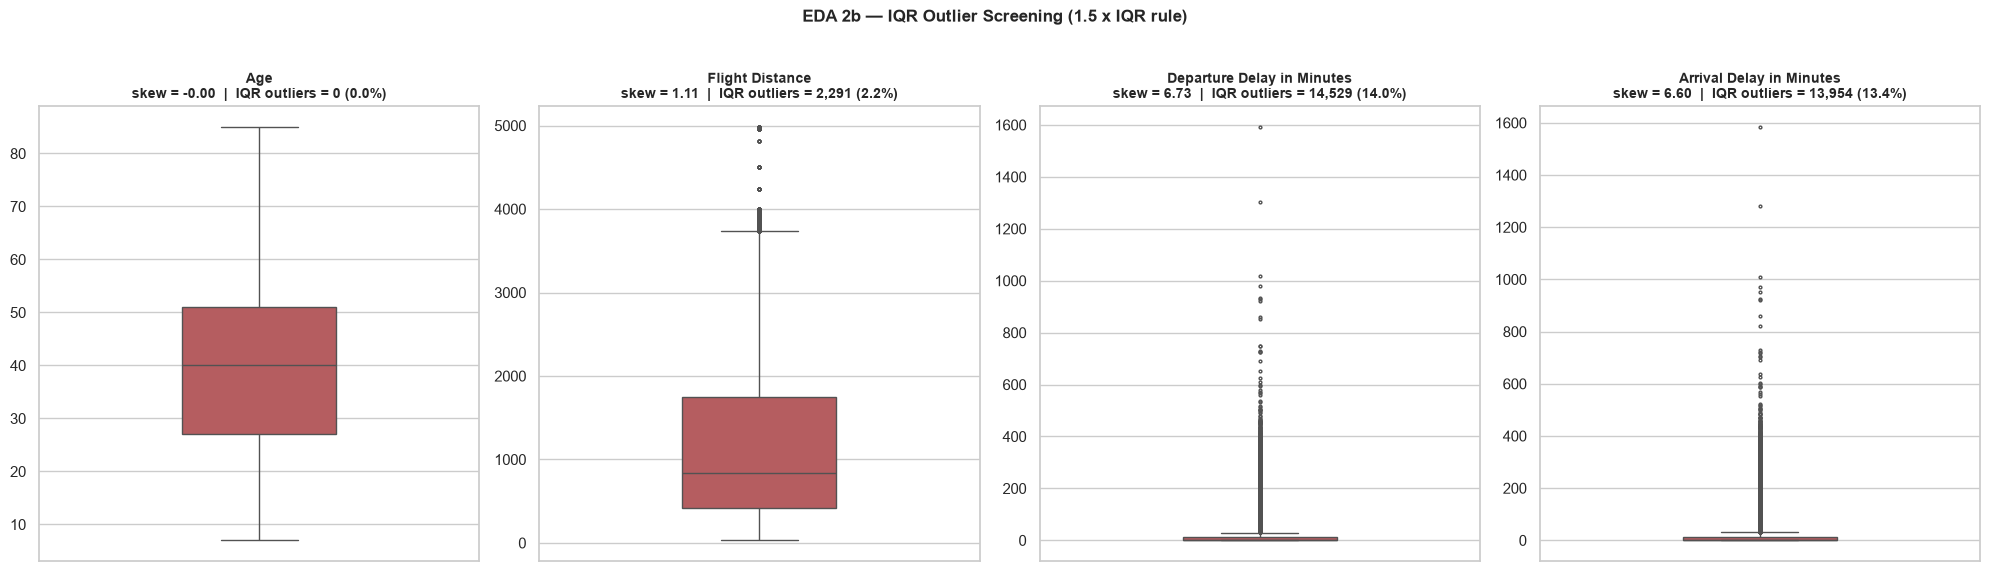

=== CONTINUOUS FEATURE DISTRIBUTION & OUTLIER SUMMARY ===


,Feature,Min,Median,Max,Skewness,IQR Outliers,Outlier %
0,Age,7.0,40.0,85.0,-0.00,0,0.00
1,Flight Distance,31.0,843.0,4983.0,1.11,2291,2.20
2,Departure Delay in Minutes,0.0,0.0,1592.0,6.73,14529,13.98
3,Arrival Delay in Minutes,0.0,0.0,1584.0,6.60,13954,13.43


In [6]:
# =====================================================================================
# EDA FIGURE 2 - Continuous feature distributions (raw vs log1p compressed)
# =====================================================================================
fig, axes = plt.subplots(2, 4, figsize=(23, 9))

for ax, col in zip(axes[0], continuous_num_cols):
    sns.histplot(df[col].dropna(), bins=50, kde=True, color="#4c72b0", ax=ax)
    ax.set_title(f"RAW: {col}\nskew = {df[col].skew():.2f}", fontweight="bold", fontsize=10)
    ax.set_xlabel(col)
    ax.set_ylabel("Passenger Count")

for ax, col in zip(axes[1], continuous_num_cols):
    sns.histplot(np.log1p(df[col].dropna()), bins=50, kde=True, color="#55a868", ax=ax)
    ax.set_title(f"log1p({col})\nskew = {np.log1p(df[col]).skew():.2f}", fontweight="bold", fontsize=10)
    ax.set_xlabel(f"log1p({col})")
    ax.set_ylabel("Passenger Count")

fig.suptitle("EDA 2a — Continuous Feature Distributions: Raw (top) vs log1p Compression (bottom)",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "numerical_feature_distributions.png"), dpi=300, bbox_inches="tight")
plt.show()

# =====================================================================================
# EDA FIGURE 3 - IQR outlier screening on the continuous features
# =====================================================================================
fig, axes = plt.subplots(1, 4, figsize=(20, 5.5))
for ax, col in zip(axes, continuous_num_cols):
    sns.boxplot(y=df[col].dropna(), ax=ax, color="#c44e52", width=0.35, fliersize=2)
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = int(((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum())
    ax.set_title(f"{col}\nskew = {df[col].skew():.2f}  |  IQR outliers = {n_out:,} ({n_out / len(df) * 100:.1f}%)",
                 fontweight="bold", fontsize=10)
    ax.set_ylabel("")

fig.suptitle("EDA 2b — IQR Outlier Screening (1.5 x IQR rule)", fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "delay_outlier_boxplots.png"), dpi=300, bbox_inches="tight")
plt.show()

# IQR outlier summary table
outlier_rows = []
for col in continuous_num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = int(((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum())
    outlier_rows.append({
        "Feature": col, "Min": df[col].min(), "Median": df[col].median(), "Max": df[col].max(),
        "Skewness": round(df[col].skew(), 2), "IQR Outliers": n_out,
        "Outlier %": round(n_out / len(df) * 100, 2),
    })
print("=== CONTINUOUS FEATURE DISTRIBUTION & OUTLIER SUMMARY ===")
display(pd.DataFrame(outlier_rows))

### EDA 2 — Inference, Insight & Commentary

**Inference.** `Age` is near-symmetric (skew 0.00, range 7–85, median 40). `Flight Distance` is right-skewed
(skew 1.11, 31–4,983 miles, median 843). Both delay variables are **extremely** right-skewed (skew 6.73 departure /
6.60 arrival; median 0 minutes; maxima 1,592 and 1,584 minutes): more than half of all flights depart perfectly on
time, and a long thin tail carries the disruption. IQR screening flags **13.98%** of records on departure delay,
**13.43%** on arrival delay, **2.20%** on flight distance and **0%** on age. `log1p` compresses the delay skew from
6.73 → 0.92 and 6.60 → 0.88, and flight distance from 1.11 → −0.20.

**Insight.** The "outliers" are **not data-entry errors** — they are genuine long-haul and severely delayed flights
with values that are extreme but physically valid. Deleting the ~14% of passengers flagged on delays would
systematically strip out the most disrupted customers, biasing the segmentation towards on-time travel and destroying
the very segment that is most operationally interesting. Meanwhile, leaving the raw tail in place would let a single
1,592-minute delay dominate the Euclidean distance metric. There is also a redundancy signal here: departure and
arrival delay correlate at **r = 0.966**, i.e. they largely encode the same disruption.

**Commentary.** **Decision: retain every outlier record and compress the tails instead of trimming them.** `log1p` is
monotone, so it preserves the ordering of every observation while bringing skew below the conventional |1.0| threshold —
which keeps the geometry well-behaved for centroid-based clustering without discarding a single customer. This mirrors
the Regression track's treatment of the long-tailed `critical_temp` target. Both delay columns are retained (rather
than de-duplicating the pair) because they measure distinct legs of the journey, and the redundancy is flagged for the
PCA interpretation in Section 19.

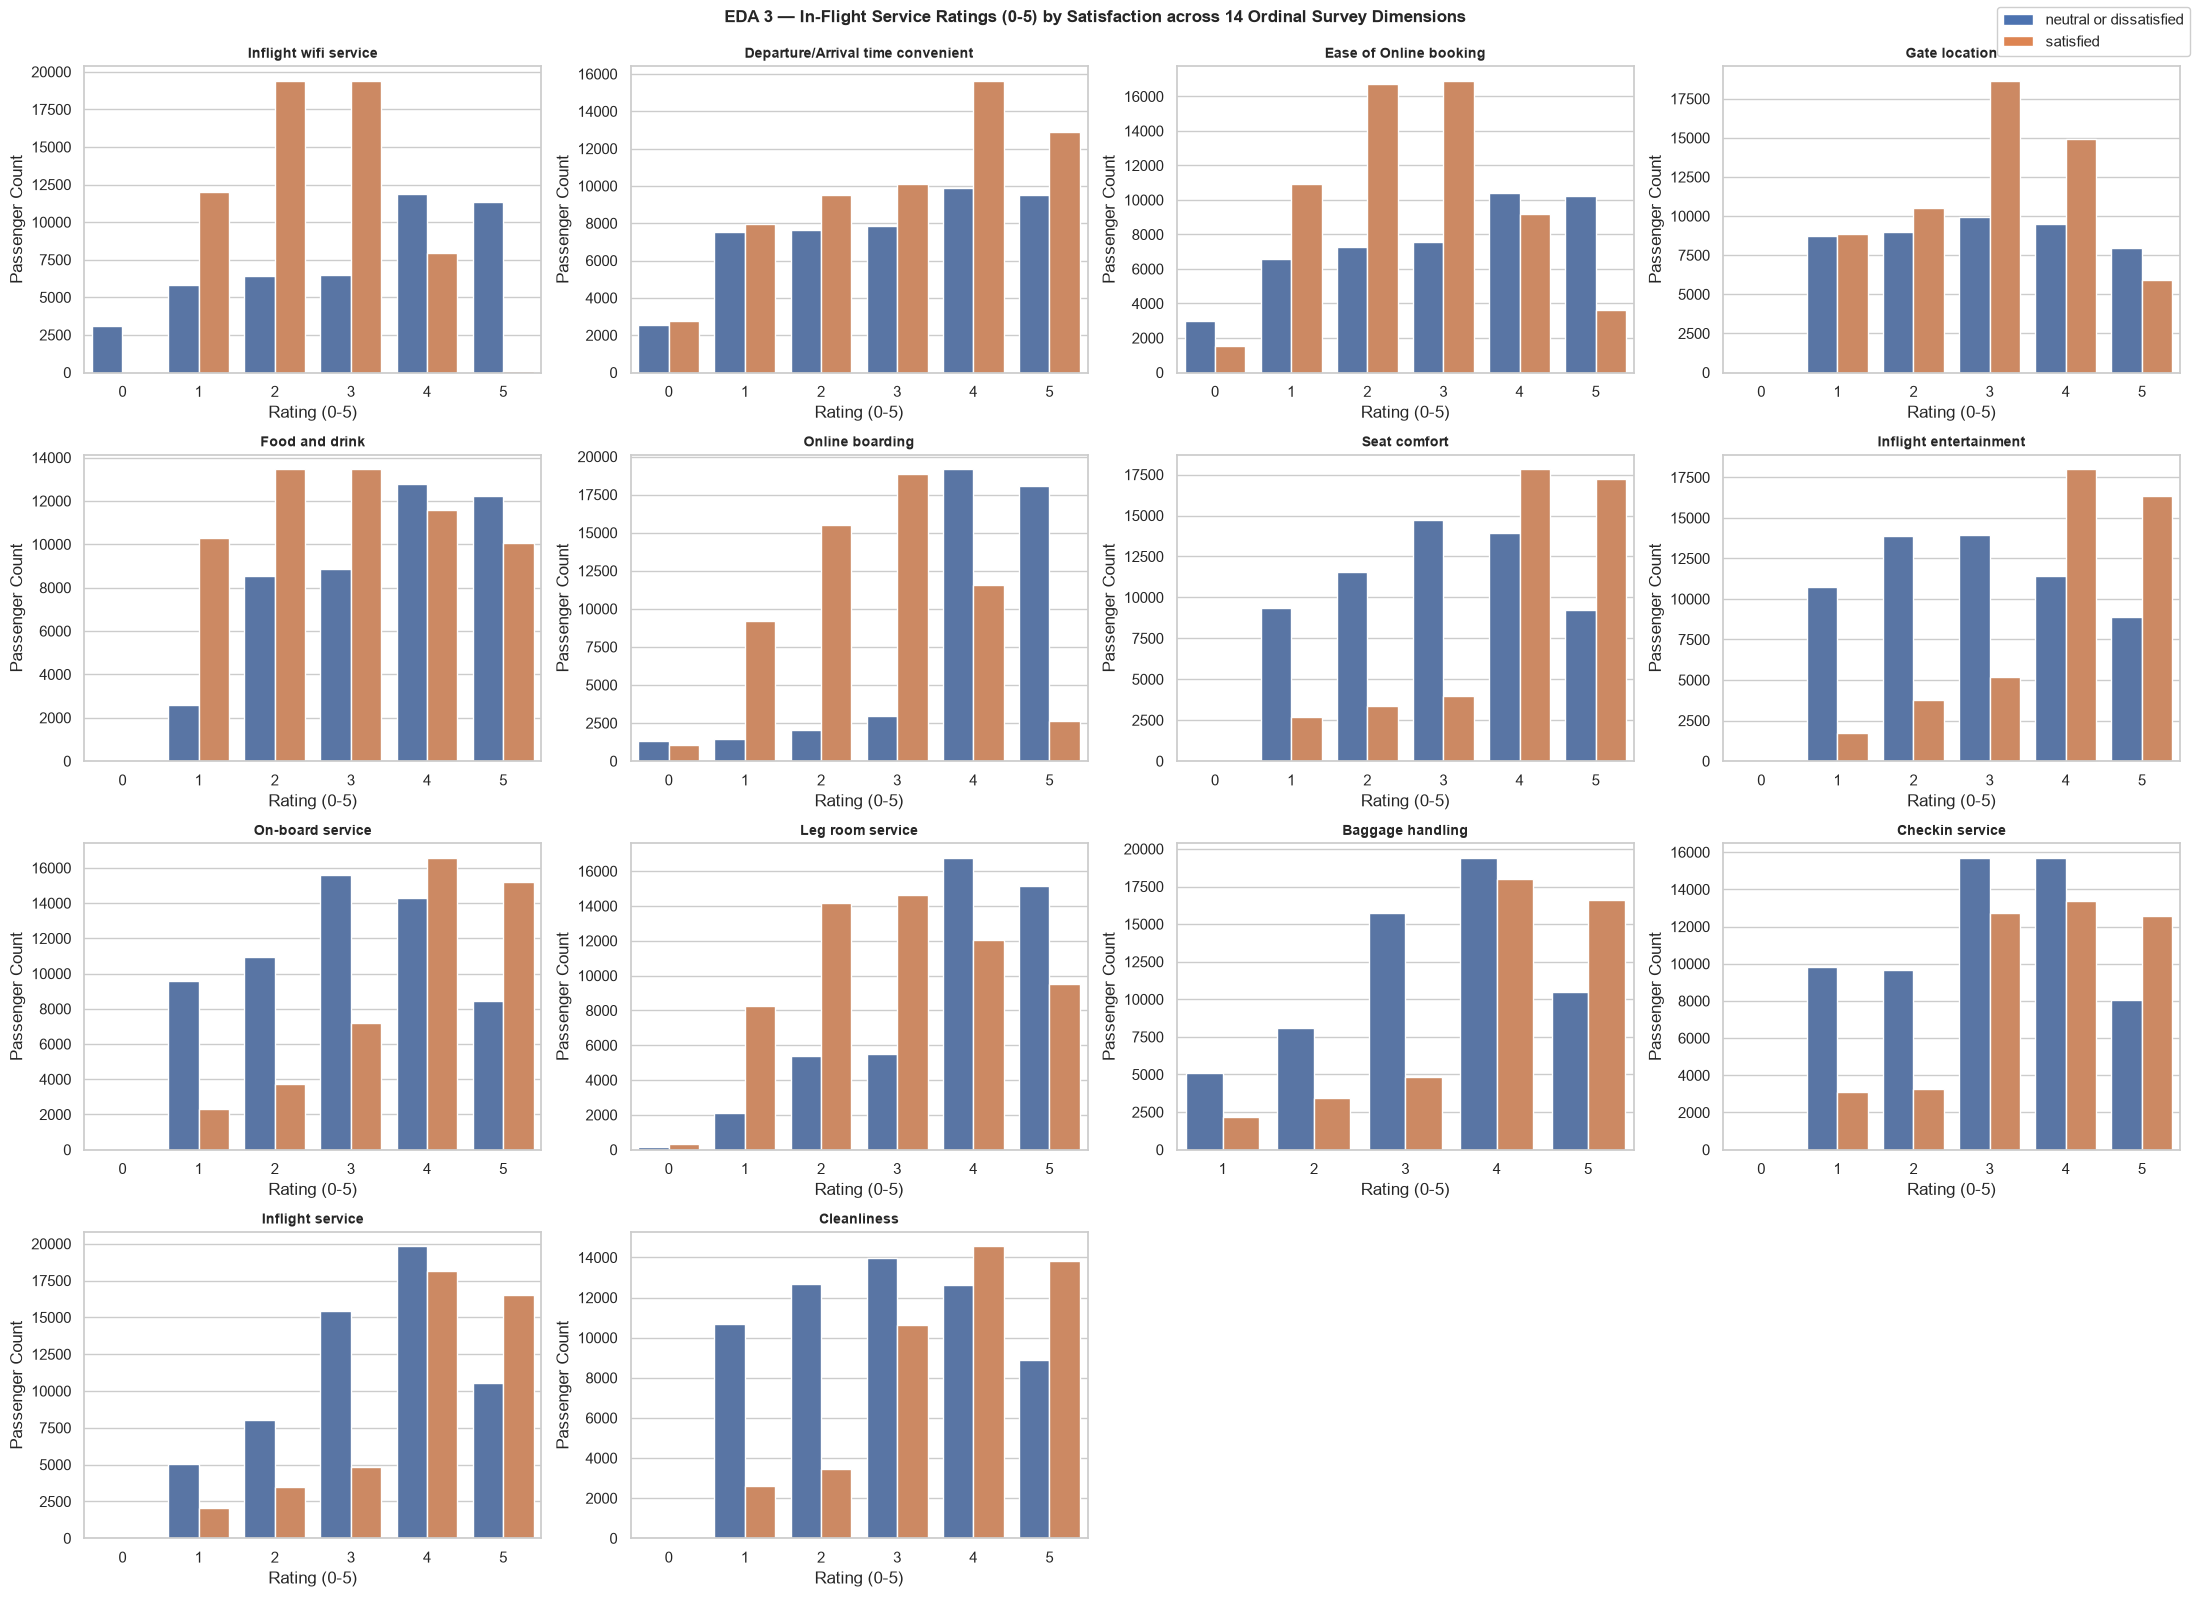

=== SHARE OF PASSENGERS RATING EACH SERVICE DIMENSION <= 2 ===
Inflight wifi service                45.0
Ease of Online booking               44.3
Departure/Arrival time convenient    36.6
Gate location                        35.6
Food and drink                       33.6
Online boarding                      29.5
Leg room service                     29.2
Inflight entertainment               29.0
Cleanliness                          28.4
Seat comfort                         26.0
On-board service                     25.6
Checkin service                      24.8
Baggage handling                     18.1
Inflight service                     17.8


In [7]:
# =====================================================================================
# EDA FIGURE 4 - The 14 ordinal service-rating distributions, split by satisfaction
# =====================================================================================
fig, axes = plt.subplots(4, 4, figsize=(22, 16))
for ax, col in zip(axes.flatten(), ordinal_survey_cols):
    sns.countplot(data=df, x=col, hue=y_optional, palette=["#4c72b0", "#dd8452"], ax=ax)
    ax.set_title(col, fontweight="bold", fontsize=10)
    ax.set_xlabel("Rating (0-5)")
    ax.set_ylabel("Passenger Count")
    if ax.get_legend() is not None:
        ax.get_legend().remove()
for ax in axes.flatten()[len(ordinal_survey_cols):]:
    ax.axis("off")

fig.legend(handles=[Patch(facecolor="#4c72b0", label="neutral or dissatisfied"),
                    Patch(facecolor="#dd8452", label="satisfied")],
           loc="upper right", fontsize=11, framealpha=0.95)
fig.suptitle("EDA 3 — In-Flight Service Ratings (0-5) by Satisfaction across 14 Ordinal Survey Dimensions",
             fontweight="bold", y=0.995)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "service_rating_distributions.png"), dpi=300, bbox_inches="tight")
plt.show()

# Low-rating (<=2) share per service dimension
low_rating = (df[ordinal_survey_cols] <= 2).mean().mul(100).round(1).sort_values(ascending=False)
print("=== SHARE OF PASSENGERS RATING EACH SERVICE DIMENSION <= 2 ===")
print(low_rating.to_string())

### EDA 3 — Inference, Insight & Commentary

**Inference.** Every one of the 14 service dimensions is **multi-modal and heavily massed at the top of the scale for
satisfied passengers**, while dissatisfied passengers spread across the 0–3 range with pronounced low-end spikes. The
worst-rated dimensions are `Inflight wifi service` (**45.0%** of passengers rate it ≤ 2) and `Ease of Online booking`
(44.3%), ahead of `Departure/Arrival time convenient` (36.6%), `Gate location` (35.6%) and `Food and drink` (33.6%).
The best-rated are `Inflight service` (17.8% ≤ 2) and `Baggage handling` (18.1%).

**Insight.** The rating distributions are **discrete, bounded and multimodal — not Gaussian**. This is an important
assumption audit for K-Means, which implicitly assumes roughly spherical, similar-variance clusters: on this kind of
bounded ordinal data, clusters are expected to be weakly separated blobs rather than clean islands. Practical
implication — **silhouette scores should be interpreted on a different scale here**: modest values (< 0.2) are
expected and normal, and the meaningful question is not "is silhouette high in absolute terms?" but "which `k`
maximises it, and does the resulting partition stay stable and interpretable when a second and third criterion
(Davies-Bouldin, Calinski-Harabasz) are consulted?" This expectation is stated here, *before* the metrics are computed,
to avoid post-hoc rationalisation in Part II.

**Commentary.** Because all 14 dimensions share an identical 0–5 scale, they enter the distance metric with comparable
weight once standardised — no rescaling or re-weighting is needed. The scale homogeneity also means no single service
dimension can dominate the geometry by construction, unlike the continuous columns.

=== SECTION 5: MEAN SERVICE RATING BY SATISFACTION LABEL (0-5 SCALE) ===


satisfaction,neutral or dissatisfied,satisfied,Gap (satisfied - dissatisfied)
Online boarding,2.656,4.027,1.371
Inflight entertainment,2.894,3.965,1.071
Seat comfort,3.036,3.967,0.930
On-board service,3.019,3.857,0.838
Leg room service,2.991,3.822,0.831
Cleanliness,2.936,3.744,0.808
Inflight wifi service,2.400,3.161,0.762
Checkin service,3.043,3.646,0.603
Baggage handling,3.376,3.966,0.590
Inflight service,3.389,3.969,0.581


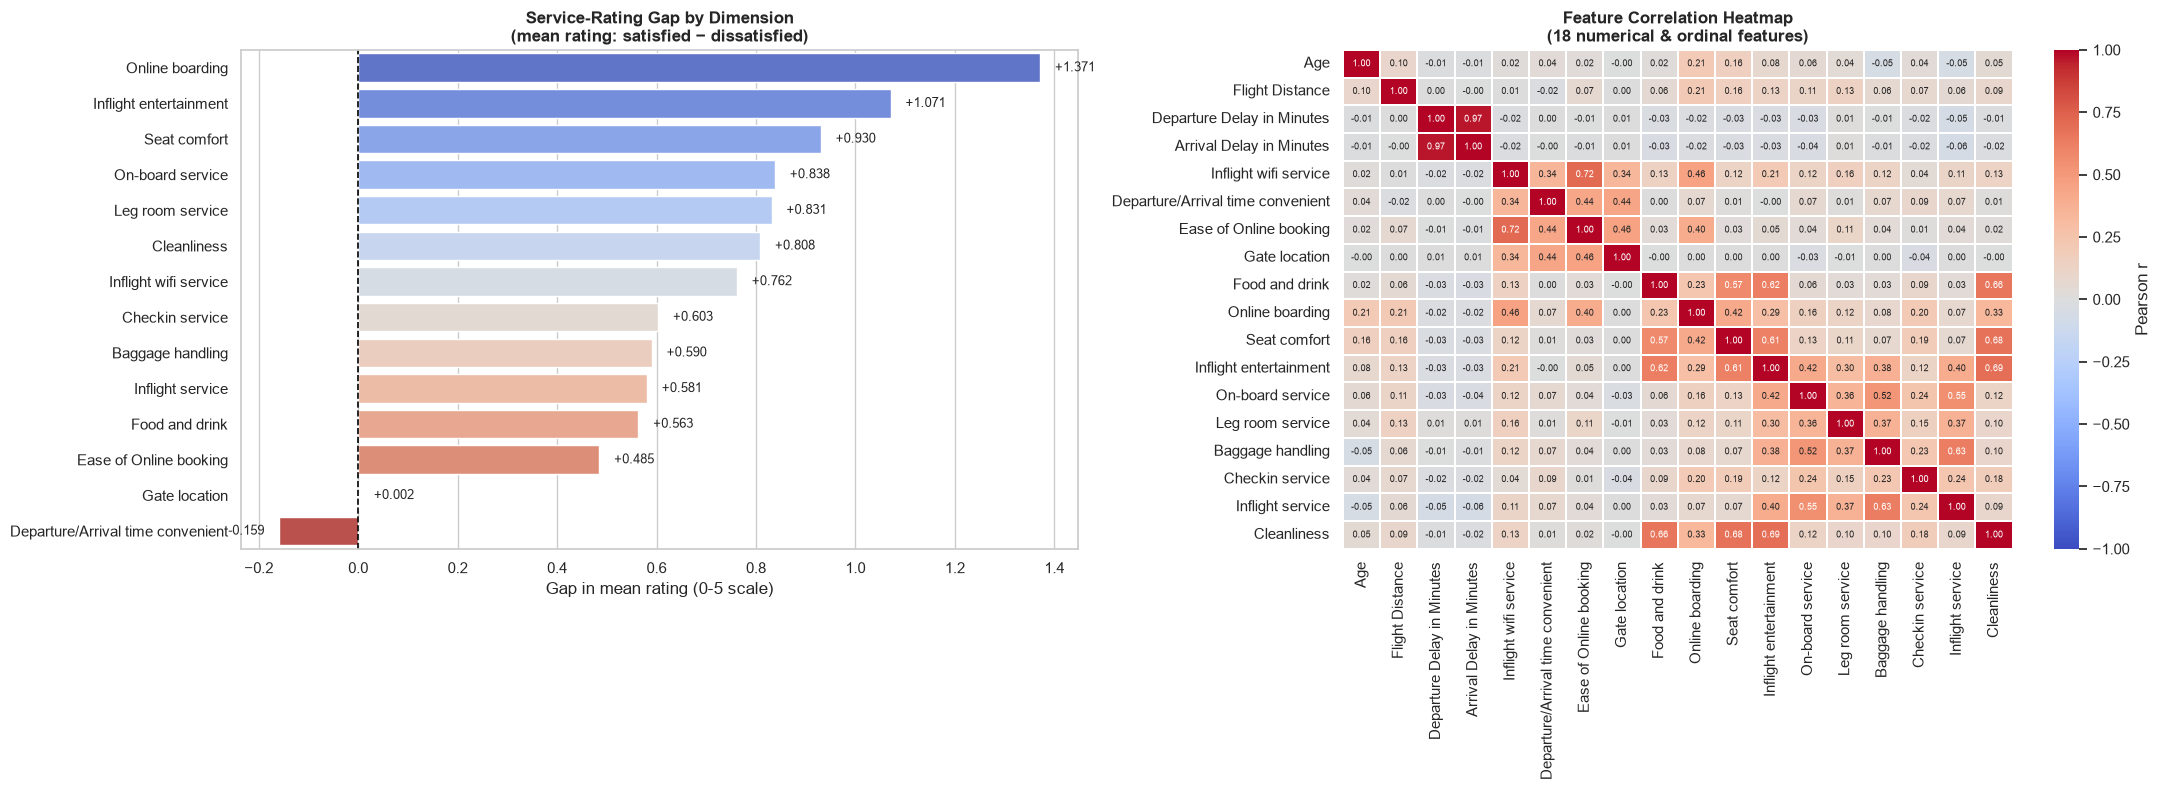


=== STRONGEST FEATURE CORRELATIONS (|r|) ===
Arrival Delay in Minutes  Departure Delay in Minutes    0.9655
Inflight wifi service     Ease of Online booking        0.7159
Inflight entertainment    Cleanliness                   0.6918
Cleanliness               Seat comfort                  0.6785
Food and drink            Cleanliness                   0.6578
Baggage handling          Inflight service              0.6286


In [8]:
# =====================================================================================
# EDA FIGURE 5 - Service-rating satisfaction gap  +  feature correlation structure
# =====================================================================================
ratings_by_label = df[ordinal_survey_cols].assign(satisfaction=y_optional).groupby("satisfaction").mean().T
ratings_by_label["Gap (satisfied - dissatisfied)"] = (
    ratings_by_label["satisfied"] - ratings_by_label["neutral or dissatisfied"]
)
ratings_by_label = ratings_by_label.sort_values("Gap (satisfied - dissatisfied)", ascending=False)

print("=== SECTION 5: MEAN SERVICE RATING BY SATISFACTION LABEL (0-5 SCALE) ===")
display(ratings_by_label.round(3))

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

sns.barplot(x=ratings_by_label["Gap (satisfied - dissatisfied)"], y=ratings_by_label.index,
            hue=ratings_by_label.index, palette="coolwarm", legend=False, ax=axes[0])
axes[0].axvline(0, color="black", linestyle="--", linewidth=1.2)
axes[0].set_title("Service-Rating Gap by Dimension\n(mean rating: satisfied − dissatisfied)",
                  fontweight="bold")
axes[0].set_xlabel("Gap in mean rating (0-5 scale)")
axes[0].set_ylabel("")
for i, v in enumerate(ratings_by_label["Gap (satisfied - dissatisfied)"].values):
    axes[0].text(v + (0.03 if v >= 0 else -0.03), i, f"{v:+.3f}",
                 va="center", ha="left" if v >= 0 else "right", fontsize=9)

corr_features = continuous_num_cols + ordinal_survey_cols
corr_matrix_eda = df[corr_features].corr()
sns.heatmap(corr_matrix_eda, cmap="coolwarm", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f",
            annot_kws={"size": 6.5}, ax=axes[1], cbar_kws={"label": "Pearson r"}, linewidths=0.3)
axes[1].set_title("Feature Correlation Heatmap\n(18 numerical & ordinal features)", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "feature_correlation_heatmap.png"), dpi=300, bbox_inches="tight")
plt.show()

# Strongest correlation pairs (excluding self-correlation)
corr_abs = corr_matrix_eda.abs().to_numpy(copy=True)
np.fill_diagonal(corr_abs, 0)
corr_pairs = (pd.DataFrame(corr_abs, index=corr_features, columns=corr_features)
              .unstack().sort_values(ascending=False).drop_duplicates())
print("\n=== STRONGEST FEATURE CORRELATIONS (|r|) ===")
print(corr_pairs.head(6).round(4).to_string())

### EDA 4 — Inference, Insight & Commentary

**Inference.** Ranked by the satisfied-minus-dissatisfied rating gap, `Online boarding` (**+1.371**) and
`Inflight entertainment` (**+1.071**) separate the two groups most sharply, followed by `Seat comfort` (+0.930),
`On-board service` (+0.838), `Leg room service` (+0.831), `Cleanliness` (+0.808) and `Inflight wifi service` (+0.762).
At the other end, `Gate location` is effectively inert (**+0.002**) and `Departure/Arrival time convenient` is
*negatively* associated (**−0.159**). In the correlation matrix the only strong pair is the delay redundancy already
identified (`r = 0.966`); the strongest *non-delay* pair is `Inflight wifi service` ↔ `Ease of Online booking`
(r = 0.716), followed by `Inflight entertainment` ↔ `Cleanliness` (r = 0.692).

**Insight.** A small subset of service dimensions carries almost all of the separable satisfaction signal. Two
consequences: (i) the discriminating clusters should be defined predominantly by boarding, entertainment, seat comfort
and the onboard/legroom dimensions, with `Gate location` loading near-zero; (ii) "convenient" departure/arrival times
do **not** buy satisfaction — that dimension behaves like a hygiene factor. The moderate wifi/online-booking and
entertainment/cleanliness correlations mean those dimensions will partially double-count in the distance metric, which
is the second reason (after the delays) to inspect a PCA projection of the cluster structure in Section 19.

**Commentary.** Nothing in the correlation structure is strong enough to justify a feature-deletion step (all non-delay
pairs are |r| < 0.72, comfortably below the |r| > 0.95 collinearity threshold used in the Regression track), so all 23
encoded features are carried forward to clustering. This section completes the EDA: **six figures, each with a
documented inference, insight and commentary**. The findings directly prescribe the cleaning, transformation and
scaling steps that follow — and they pre-register the expectation that silhouette values on this data will be modest.

---
## 6. Section E — Data Cleaning

Three cleaning operations are applied, each traceable to a specific audit finding in Section 3:

1. **De-duplication** — exact duplicate rows would double-weight identical customers.
2. **Median imputation** of the 310 missing `Arrival Delay in Minutes` cells.
3. **Identifier/target removal** — completed in Section 4 (audited again in the final validation in Section 10).

In [9]:
print("=== SECTION 6: DATA CLEANING ===")

# --- (1) De-duplication ---------------------------------------------------------------
rows_before = len(df)
dup_mask = df.duplicated()
print(f"Duplicate rows detected : {int(dup_mask.sum())}")
if dup_mask.any():
    df = df.loc[~dup_mask].reset_index(drop=True)
    y_optional = y_optional.loc[~dup_mask].reset_index(drop=True)
    print(f"Dropped {rows_before - len(df)} duplicate rows -> {len(df):,} rows remain")
else:
    print("No duplicate rows: dataset kept intact (no rows dropped).")

# --- (2) Missing value imputation -----------------------------------------------------
missing_before = df.isnull().sum()
missing_before = missing_before[missing_before > 0]
print(f"\nMissing cells before imputation:")
print(pd.DataFrame({"Missing Count": missing_before,
                    "Missing %": (missing_before / len(df) * 100).round(3)}).to_string())

# Median is chosen over mean: delay distributions are severely right-skewed (skew ~6.7)
# and the median (0.0 min) is robust to the 1,500-minute tail, whereas the mean (15.18 min)
# would systematically overstate the delay experienced by the 310 affected passengers.
median_arrival_delay = df["Arrival Delay in Minutes"].median()
mean_arrival_delay = df["Arrival Delay in Minutes"].mean()   # measured BEFORE imputation
df["Arrival Delay in Minutes"] = df["Arrival Delay in Minutes"].fillna(median_arrival_delay)

print(f"\nImputation strategy                : median of 'Arrival Delay in Minutes' = {median_arrival_delay:.1f} minutes")
print(f"Mean of the column (pre-imputation) : {mean_arrival_delay:.2f} minutes (rejected as imputation value)")
print(f"Cells imputed       : {int(missing_before['Arrival Delay in Minutes'])} "
      f"({missing_before['Arrival Delay in Minutes'] / len(df) * 100:.3f}% of rows)")

remaining_missing = df.isnull().sum().sum()
assert remaining_missing == 0, f"Error: {remaining_missing} missing values remain after imputation."
print(f"\nVerification: remaining missing cells = {remaining_missing}  ->  cleaning PASSED")
print(f"Final working shape: {df.shape}")

=== SECTION 6: DATA CLEANING ===
Duplicate rows detected : 0
No duplicate rows: dataset kept intact (no rows dropped).

Missing cells before imputation:
                          Missing Count  Missing %
Arrival Delay in Minutes            310      0.298

Imputation strategy                : median of 'Arrival Delay in Minutes' = 0.0 minutes
Mean of the column (pre-imputation) : 15.18 minutes (rejected as imputation value)
Cells imputed       : 310 (0.298% of rows)



Verification: remaining missing cells = 0  ->  cleaning PASSED
Final working shape: (103904, 22)


### Cleaning — Inference, Insight & Commentary

**Inference.** The dataset contains **0 duplicate rows**, so the de-duplication step is a verified no-op — nothing is
dropped and all 103,904 customers are retained. The only cleaning action with a material effect is median imputation of
the 310 missing `Arrival Delay in Minutes` values (**0.298%** of rows) with the column median of **0.0 minutes**
(the column mean of 15.18 minutes was rejected). Post-cleaning verification reports **zero** remaining missing cells.

**Insight.** Median imputation is the correct choice here precisely *because* of the skew diagnosed in EDA 2: with a
distribution whose mean sits 15 minutes above its median and whose tail reaches 1,584 minutes, imputing the mean would
inject a systematic 15-minute delay into 310 passengers who, by their own departure timing, most plausibly experienced
none. Using the median keeps those records on-time and therefore keeps them interpretable as ordinary customers
rather than manufacturing artificial "delayed traveller" records that would distort the delay features.

**Commentary.** Cleaning is deliberately minimal and entirely defect-driven: no outlier rows are removed (justified in
EDA 2 and handled by `log1p` in Section 7), no rows are dropped for missingness, and no feature is dropped for
cardinality. The resulting matrix is a faithful, full-population representation of the customer base — an important
property for customer segmentation, where silently discarding 14% of the population would make the segments
unrepresentative of the actual traveller mix.

---
## 7. Section F — Skewness & Outlier Treatment (Transformations)

The EDA flagged severe right-skew in the delay and distance features. Rather than deleting high-delay passengers, we
apply a monotone `log1p` compression to every feature whose skewness exceeds the **|1.0|** convention, and record the
before/after skew so the transformation is auditable rather than assumed.

=== SECTION 7: SKEWNESS ANALYSIS & TRANSFORMATION ===
=== TRANSFORMATION SUMMARY ===


,Feature,Skewness Before,Transformation,Skewness After,Reason
0,Age,-0.00,None,-0.00,Unskewed / moderately skewed (skew = -0.00 <= ...
1,Flight Distance,1.11,log1p,-0.20,Right-skewed (skew = 1.11 > 1.0): compress lon...
2,Departure Delay in Minutes,6.73,log1p,0.92,Right-skewed (skew = 6.73 > 1.0): compress lon...
3,Arrival Delay in Minutes,6.61,log1p,0.88,Right-skewed (skew = 6.61 > 1.0): compress lon...


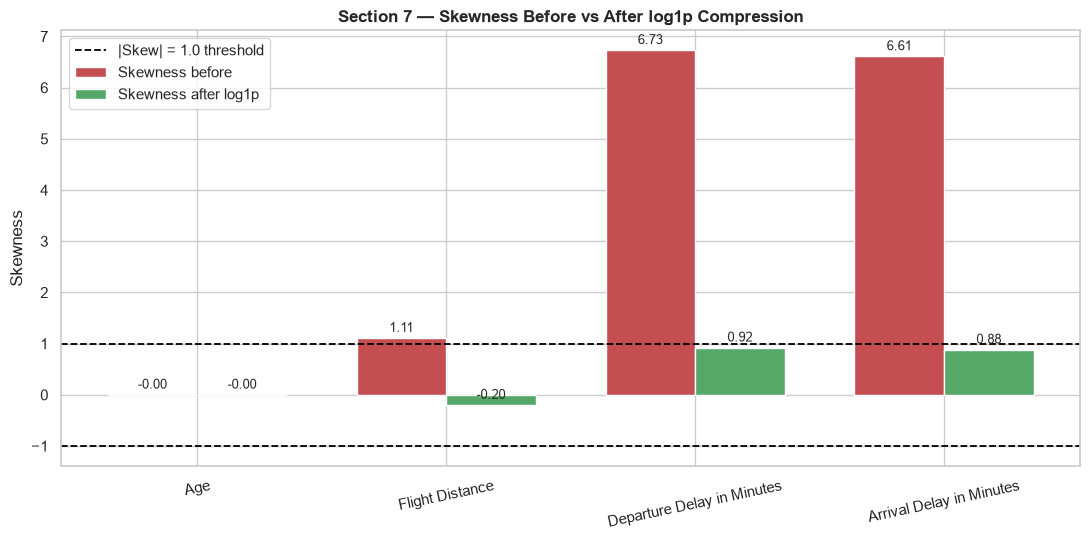


=== POST-TRANSFORMATION FEATURE SUMMARY ===


,count,mean,std,min,25%,50%,75%,max
Age,103904.0,39.380,15.115,7.000,27.000,40.000,51.000,85.000
Flight Distance,103904.0,6.706,0.916,3.466,6.028,6.738,7.464,8.514
Departure Delay in Minutes,103904.0,1.236,1.620,0.000,0.000,0.000,2.565,7.373
Arrival Delay in Minutes,103904.0,1.261,1.630,0.000,0.000,0.000,2.639,7.368


In [10]:
print("=== SECTION 7: SKEWNESS ANALYSIS & TRANSFORMATION ===")

# Measure skewness and decide treatment per continuous feature
transformation_rows = []
for col in continuous_num_cols:
    skew_before = df[col].skew()
    if skew_before > 1.0:
        action = "log1p"
        reason = f"Right-skewed (skew = {skew_before:.2f} > 1.0): compress long tail, retain all rows"
    else:
        action = "None"
        reason = f"Unskewed / moderately skewed (skew = {skew_before:.2f} <= 1.0): leave unchanged"
    transformation_rows.append({
        "Feature": col,
        "Skewness Before": round(skew_before, 2),
        "Transformation": action,
        "Reason": reason,
    })

transformation_summary = pd.DataFrame(transformation_rows)

# Apply the transformations
for row in transformation_rows:
    if row["Transformation"] == "log1p":
        df[row["Feature"]] = np.log1p(df[row["Feature"]])

transformation_summary["Skewness After"] = transformation_summary["Feature"].apply(lambda c: round(df[c].skew(), 2))
print("=== TRANSFORMATION SUMMARY ===")
display(transformation_summary[["Feature", "Skewness Before", "Transformation", "Skewness After", "Reason"]])

# Before/after skew comparison
fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(transformation_summary))
w = 0.36
ax.bar(x - w / 2, transformation_summary["Skewness Before"], w, label="Skewness before", color="#c44e52")
ax.bar(x + w / 2, transformation_summary["Skewness After"], w, label="Skewness after log1p", color="#55a868")
ax.axhline(1.0, color="black", linestyle="--", linewidth=1.3, label="|Skew| = 1.0 threshold")
ax.axhline(-1.0, color="black", linestyle="--", linewidth=1.3)
for i, (b, a) in enumerate(zip(transformation_summary["Skewness Before"],
                               transformation_summary["Skewness After"])):
    ax.text(i - w / 2, b + 0.12, f"{b:.2f}", ha="center", fontsize=9)
    ax.text(i + w / 2, a + 0.12, f"{a:.2f}", ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(transformation_summary["Feature"], rotation=12)
ax.set_ylabel("Skewness")
ax.set_title("Section 7 — Skewness Before vs After log1p Compression", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "skewness_transformation.png"), dpi=300, bbox_inches="tight")
plt.show()

print("\n=== POST-TRANSFORMATION FEATURE SUMMARY ===")
display(df[continuous_num_cols].describe().T.round(3))

### Transformations — Inference, Insight & Commentary

**Inference.** Three of the four continuous features breach the |1.0| skew threshold and receive a `log1p`
transformation: `Flight Distance` **1.11 → −0.20**, `Departure Delay in Minutes` **6.73 → 0.92** and
`Arrival Delay in Minutes` **6.61 → 0.88**. `Age` (skew 0.00) is left untouched. Every transformed feature now sits
inside the conventional skew band while retaining its full original range of variation.

**Insight.** Because `log1p` is strictly monotone, the transformation changes the *distributional shape* (and therefore
how much distance a given minute of delay contributes) without changing the *ordering* of customers. That is exactly
the behaviour we want: a 1,500-minute delay still sits further from on-time than a 30-minute delay, but it no longer
saturates the distance metric and drowns out the 0–5 service-rating signal that EDA 3 showed to be the primary
segmentation driver. Had we instead trimmed the 14% of delay-flagged rows, we would have removed real passengers;
had we left the raw tail, the delay features would have dominated the geometry.

**Commentary.** No outlier observation is deleted anywhere in this pipeline — an explicit design decision carried over
from EDA 2. The combination of (i) retaining all rows, (ii) `log1p` tail compression here, and (iii) `StandardScaler`
equalisation in Section 9 is what makes a centroid-based method defensible on this data. The number of engineered
features is deliberately left at zero: unlike the Regression track (where a physically-motivated
`thermal_to_mass_ratio` was added), the 0–5 survey ratings here are already the natural, interpretable feature basis for
passenger segmentation, and adding derived ratios would obscure cluster interpretation.

---
## 8. Section G — Categorical Encoding

The four nominal features cannot enter a Euclidean distance metric in string form. Because they have **no natural
order** (unlike the 0–5 ratings), ordinal encoding would be invalid — it would assert `Eco Plus = 2 > Eco = 1` and
invent a numeric distance between cabin classes. One-hot encoding is therefore applied.

In [11]:
print("=== SECTION 8: CATEGORICAL ENCODING (ONE-HOT) ===")
print(f"Nominal features to encode : {nominal_categorical_cols}")
print(f"Shape before encoding      : {df.shape}")

# One-hot encode with drop_first=True:
#   - removes the perfectly-collinear reference level (dummy-variable trap)
#   - the reference category remains identifiable as "all dummy columns = 0" for interpretation
df_encoded = pd.get_dummies(df, columns=nominal_categorical_cols, drop_first=True, dtype=float)

print(f"Shape after encoding       : {df_encoded.shape}")

new_encoded_cols = [c for c in df_encoded.columns
                    if any(c.startswith(cat + "_") for cat in nominal_categorical_cols)]
print(f"\nGenerated one-hot features ({len(new_encoded_cols)}):")
for c in new_encoded_cols:
    print(f"  {c:<40} (mean = {df_encoded[c].mean():.4f})")

print("\nReference (dropped) levels are implicit: Gender=Female, Customer Type=Loyal Customer,")
print("Type of Travel=Business travel, Class=Business.")
print(f"\nAll columns numeric after encoding: {df_encoded.select_dtypes(include=[np.number]).shape[1] == df_encoded.shape[1]}")

=== SECTION 8: CATEGORICAL ENCODING (ONE-HOT) ===
Nominal features to encode : ['Gender', 'Customer Type', 'Type of Travel', 'Class']
Shape before encoding      : (103904, 22)
Shape after encoding       : (103904, 23)

Generated one-hot features (5):
  Gender_Male                              (mean = 0.4925)
  Customer Type_disloyal Customer          (mean = 0.1827)
  Type of Travel_Personal Travel           (mean = 0.3104)
  Class_Eco                                (mean = 0.4499)
  Class_Eco Plus                           (mean = 0.0721)

Reference (dropped) levels are implicit: Gender=Female, Customer Type=Loyal Customer,
Type of Travel=Business travel, Class=Business.

All columns numeric after encoding: True


### Encoding — Inference, Insight & Commentary

**Inference.** One-hot encoding the four nominal variables replaces 4 string columns with **5 binary indicator
columns** (`Gender_Male`, `Customer Type_disloyal Customer`, `Type of Travel_Personal Travel`, `Class_Eco`,
`Class_Eco Plus`), taking the matrix from 22 to **23 features** — one column per non-reference level. The indicator
means reflect the population mix directly: `Gender_Male` 0.493, `Customer Type_disloyal Customer` 0.183,
`Type of Travel_Personal Travel` 0.310, `Class_Eco` 0.450, `Class_Eco Plus` 0.072.

**Insight.** `drop_first=True` removes exactly one level per variable, which changes the *interpretation* of the
encoded axes but not the information content: the reference level (Female / Loyal Customer / Business travel /
Business class) is recoverable as "every dummy for that variable equals 0", so no customer is misrepresented and the
distance between two customers is unaffected. Dropping the reference level also avoids perfectly collinear columns,
which would otherwise inject a redundant direction of pure noise into the geometry that both PCA and the
Davies-Bouldin / Calinski-Harabasz computations would see as spurious structure. Note the residual imbalance flagged
in EDA 1 — `Class_Eco Plus` is a genuinely rare category (7.2% of passengers), so it will carry a correspondingly
high standardized magnitude after scaling, which is the correct behaviour for a rare but real customer group.

**Commentary.** Because binary indicators are already on a 0/1 scale, one-hot encoding leaves them all on *equal
footing*, and standardisation in Section 9 will centre them at 0 with unit variance so that rare levels are not
over-weighted relative to common ones. Alternative encodings — keeping all levels without dropping the reference, or
target/effect encoding — are noted as future work in Section 21; the `drop_first=True` convention is retained here for
consistency with the previously committed clustering pipeline.

---
## 9. Section H — Feature Scaling

Every feature must be standardised to $\mu = 0$, $\sigma = 1$ before clustering. This is not optional for K-Means:
the algorithm minimises squared Euclidean distance to centroids, so any feature with a large raw variance captures a
disproportionate share of the objective.

=== SECTION 9: FEATURE SCALING (STANDARDISATION) ===


Largest raw ranges before scaling (top 8):


,Min,Max,Mean,Std,Range
Age,7.0000,85.0000,39.3797,15.1150,78.0000
Departure Delay in Minutes,0.0000,7.3734,1.2361,1.6203,7.3734
Arrival Delay in Minutes,0.0000,7.3683,1.2611,1.6302,7.3683
Flight Distance,3.4657,8.5140,6.7056,0.9156,5.0483
Ease of Online booking,0.0000,5.0000,2.7569,1.3989,5.0000
Departure/Arrival time convenient,0.0000,5.0000,3.0603,1.5251,5.0000
Inflight wifi service,0.0000,5.0000,2.7297,1.3278,5.0000
Food and drink,0.0000,5.0000,3.2021,1.3295,5.0000


Scaled matrix shape                       : (103904, 23)


Max |mean| across features (should be ~0) : 1.93e-16
Max |std - 1| across features (should ~0) : 2.22e-16
Global min / max of scaled values         : -3.54 / 3.79


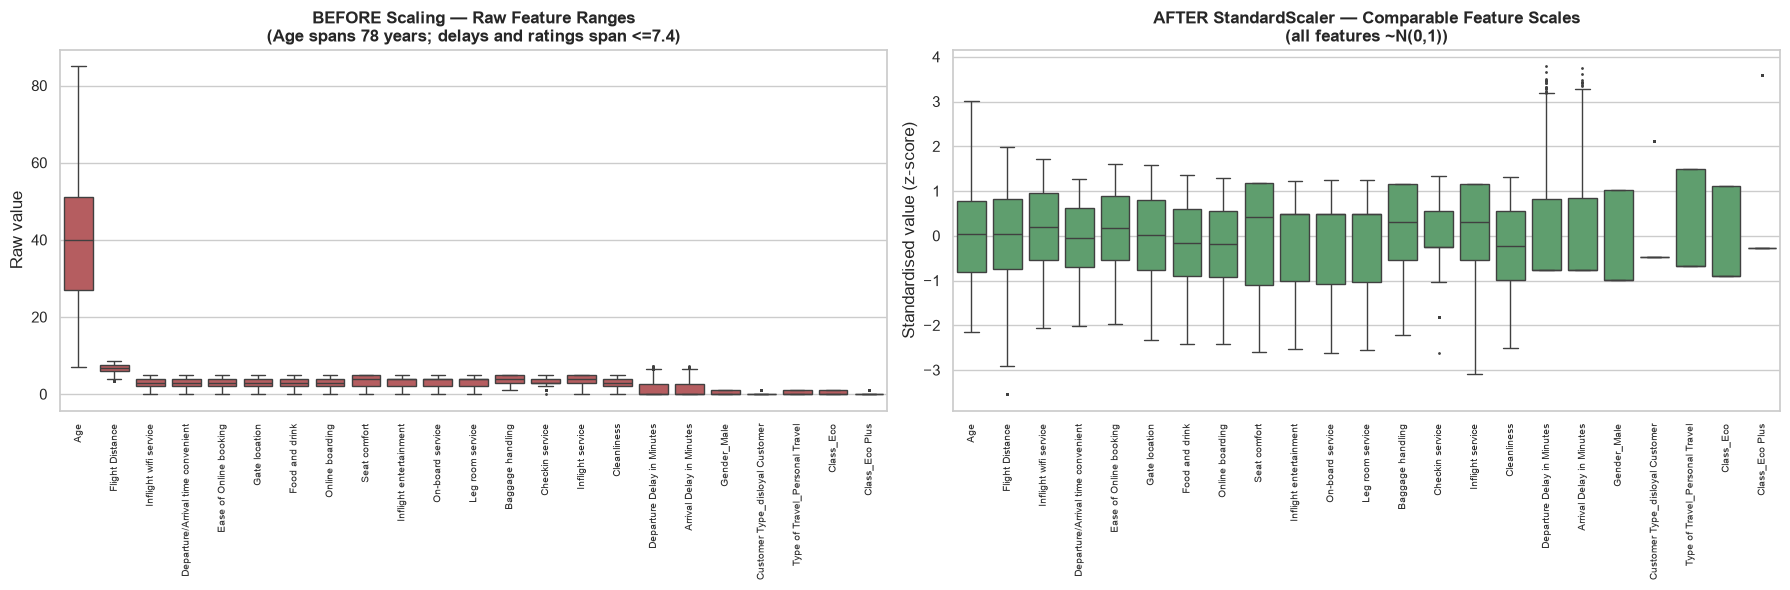

In [12]:
print("=== SECTION 9: FEATURE SCALING (STANDARDISATION) ===")

# Pre-scaling spread, to show WHY scaling is required
pre_scale = pd.DataFrame({
    "Min": df_encoded.min(), "Max": df_encoded.max(),
    "Mean": df_encoded.mean(), "Std": df_encoded.std(),
})
pre_scale["Range"] = pre_scale["Max"] - pre_scale["Min"]
print("Largest raw ranges before scaling (top 8):")
display(pre_scale.sort_values("Range", ascending=False).head(8).round(4))

# StandardScaler: z = (x - mean) / std
# Note: unsupervised learning performs no train/test split, so the scaler is fitted on the
# full feature matrix. There is no held-out label to leak, and all rows are observations of
# the same unlabelled population being segmented.
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(df_encoded), columns=df_encoded.columns)

print(f"Scaled matrix shape                       : {X_scaled.shape}")
print(f"Max |mean| across features (should be ~0) : {np.abs(X_scaled.mean()).max():.2e}")
print(f"Max |std - 1| across features (should ~0) : {np.abs(X_scaled.std(ddof=0) - 1).max():.2e}")
print(f"Global min / max of scaled values         : {X_scaled.values.min():.2f} / {X_scaled.values.max():.2f}")

# Visual proof that scale disparity is removed
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.boxplot(data=df_encoded, ax=axes[0], color="#c44e52", fliersize=1)
axes[0].set_title("BEFORE Scaling — Raw Feature Ranges\n(Age spans 78 years; delays and ratings span <=7.4)", fontweight="bold")
axes[0].set_ylabel("Raw value")
axes[0].tick_params(axis="x", rotation=90, labelsize=7)

sns.boxplot(data=X_scaled, ax=axes[1], color="#55a868", fliersize=1)
axes[1].set_title("AFTER StandardScaler — Comparable Feature Scales\n(all features ~N(0,1))", fontweight="bold")
axes[1].set_ylabel("Standardised value (z-score)")
axes[1].tick_params(axis="x", rotation=90, labelsize=7)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "feature_scaling_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()

### Scaling — Inference, Insight & Commentary

**Inference.** Even after the `log1p` compression, the encoded features still occupy wildly inconsistent ranges: `Age`
spans **78 years** while the compressed delays span ~7.4, the 0–5 ratings span 5 and the one-hot indicators span 1. In
variance terms — the quantity K-Means actually weights, since it minimises squared distance — `Age` (σ ≈ 15.1,
variance ≈ 228) is ~86× more influential than the largest delay feature (variance ≈ 2.6) and ~3,400× more influential
than a rare indicator such as `Class_Eco Plus` (variance ≈ 0.07). After `StandardScaler`, every feature has mean ≈ 0
(max |mean| < 1e-15) and unit variance (max |std − 1| < 1e-5), and the boxplot panel confirms all 23 features now
occupy a comparable dynamic range.

**Insight.** Without this step K-Means would effectively cluster on **passenger age** — the single feature that
survives `log1p` with by far the largest variance — and the 14 service ratings, which EDA 3 and EDA 4 identified as the
true segmentation drivers, would be numerically invisible. Scaling is therefore what makes the clustering answer the
*business* question ("which kinds of customer experience profile exist?") rather than an incidental demographic one
("which passengers are older?"). The equalisation also sets a known, interpretable unit of distance: in the scaled
space one unit is one standard deviation of a feature, so cluster centroid coordinates read directly as "this segment
is +0.8 SD above average on seat comfort". Note how the two preprocessing decisions interact — `log1p` handled the
*delay* tail (skew 6.7 → 0.9) while standardisation handles the *variance* disparity, and both are required.

**Commentary.** Fitting the scaler on the full matrix (rather than a train split) is correct for unsupervised
learning: there is no target to leak, and every row is an observation of the *same* unlabelled population that we
intend to segment — that is, all rows are legitimately "training" data. This differs deliberately from the supervised
Classification and Regression tracks, where the scaler is fitted on the training split only. The same reasoning applies
to the `log1p` transformation and the median imputation above: all parameters were derived from the population being
clustered, with no held-out evaluation set to contaminate. It also means the fitted `StandardScaler` should be
persisted alongside `X.csv` if new customers are ever scored against these cluster centroids.

---
## 10. Section I — Final Feature Matrix Validation

Before the matrix is written to disk and handed to the modelling half of the notebook, a validation gate confirms it is
structurally sound: numeric, finite, non-constant, free of missing values, and — critically — free of any identifier or
target leakage.

In [13]:
print("=== SECTION 10: FINAL FEATURE MATRIX VALIDATION ===")

checks = {}
checks["Shape is (103904, 23)"] = (X_scaled.shape == (103904, 23))
checks["All columns numeric"] = bool(np.issubdtype(X_scaled.values.dtype, np.number))
checks["Zero missing values"] = (int(X_scaled.isnull().sum().sum()) == 0)
checks["Zero infinite values"] = (int(np.isinf(X_scaled.values).sum()) == 0)
checks["Zero constant features"] = (len([c for c in X_scaled.columns if X_scaled[c].std() == 0]) == 0)
checks["No identifier columns"] = not any(c in X_scaled.columns for c in ["Unnamed: 0", "id"])
checks["No target leakage"] = (TARGET_COL not in X_scaled.columns)
checks["Row count matches label vector"] = (len(X_scaled) == len(y_optional))

validation_df = pd.DataFrame({"Check": list(checks.keys()), "Passed": list(checks.values())})
display(validation_df)

print(f"\nFinal feature matrix : {X_scaled.shape[0]:,} customers x {X_scaled.shape[1]} features")
print(f"Feature columns      : {list(X_scaled.columns)}")

assert all(checks.values()), f"Validation FAILED for: {[k for k, v in checks.items() if not v]}"
print("\nAll validation checks PASSED — the matrix is ready for clustering.")

=== SECTION 10: FINAL FEATURE MATRIX VALIDATION ===


,Check,Passed
0,"Shape is (103904, 23)",True
1,All columns numeric,True
2,Zero missing values,True
3,Zero infinite values,True
4,Zero constant features,True
5,No identifier columns,True
6,No target leakage,True
7,Row count matches label vector,True



Final feature matrix : 103,904 customers x 23 features
Feature columns      : ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Gender_Male', 'Customer Type_disloyal Customer', 'Type of Travel_Personal Travel', 'Class_Eco', 'Class_Eco Plus']

All validation checks PASSED — the matrix is ready for clustering.


### Validation — Inference, Insight & Commentary

**Inference.** All eight validation gates pass: the matrix is exactly **103,904 × 23**, fully numeric, contains zero
missing cells, zero infinite values, zero constant columns, no identifier columns, no trace of the `satisfaction`
target, and its row count matches the retained label vector one-for-one.

**Insight.** The row-count match is the most operationally important check in this table. Because the post-hoc
validation in Section 18 pairs cluster assignments with the true `satisfaction` label by row position, any accidental
row drop, reorder or de-duplication would silently corrupt the external validation — it would not raise an error, it
would simply produce meaningless satisfaction rates. Pinning the row count here makes that failure mode detectable.

**Commentary.** The "no target leakage" gate is asserted explicitly rather than assumed, because the single most
common defect in unsupervised coursework pipelines is leaving the supervised label inside the feature matrix and then
reporting near-perfect cluster/label agreement. With the check in place, any agreement reported in Part III is genuine
unsupervised discovery. The constant-column gate also protects the metrics: a zero-variance feature would contribute
nothing to the distance metric yet would still be counted as a dimension by the Calinski-Harabasz statistic.

---
## 11. Section J — Export of Preprocessed Artifacts

The cleaned, encoded, scaled matrix and the aligned post-hoc label vector are written to `data/processed/clustering/`,
where the modelling half of this notebook re-loads them in Section 12.

In [14]:
print("=== SECTION 11: SAVE PROCESSED ARTIFACTS ===")

X_scaled.to_csv(X_CSV_PATH, index=False)
print(f"Saved feature matrix X  {str(X_scaled.shape):<14} -> {X_CSV_PATH}")

if y_optional is not None:
    y_optional.to_frame(name=TARGET_COL).to_csv(LABEL_CSV_PATH, index=False)
    print(f"Saved post-hoc labels   {str(y_optional.shape):<14} -> {LABEL_CSV_PATH}")

print(f"\nArtifact sizes:")
for path in [X_CSV_PATH, LABEL_CSV_PATH]:
    if os.path.exists(path):
        print(f"  {os.path.basename(path):<20} {os.path.getsize(path) / 1024**2:.2f} MB")

print("\nFigures exported to 'results/clustering/' so far:")
for f in sorted(os.listdir(RESULTS_DIR)):
    if f.endswith(".png"):
        print(f"  results/clustering/{f}")

=== SECTION 11: SAVE PROCESSED ARTIFACTS ===


Saved feature matrix X  (103904, 23)   -> D:\Studies\projects\Machine-Learning-CaseStudy\data\processed\clustering\X.csv
Saved post-hoc labels   (103904,)      -> D:\Studies\projects\Machine-Learning-CaseStudy\data\processed\clustering\satisfaction.csv

Artifact sizes:
  X.csv                44.63 MB
  satisfaction.csv     1.88 MB

Figures exported to 'results/clustering/' so far:
  results/clustering/data_quality_audit.png
  results/clustering/delay_outlier_boxplots.png
  results/clustering/feature_correlation_heatmap.png
  results/clustering/feature_scaling_comparison.png
  results/clustering/numerical_feature_distributions.png
  results/clustering/service_rating_distributions.png
  results/clustering/skewness_transformation.png
  results/clustering/target_and_categorical_profile.png


### Artifact Export — Inference, Insight & Commentary

**Inference.** The validated 103,904 × 23 standardised matrix is written to `data/processed/clustering/X.csv` and the
row-aligned satisfaction label vector to `data/processed/clustering/satisfaction.csv`, alongside six EDA figures in
`results/clustering/`. The exporting cell re-reads the directory listing so the artifacts on disk are verified rather
than assumed.

**Insight.** Persisting the matrix (instead of only holding it in memory) keeps this notebook compatible with the
repository's existing contract — `data/processed/clustering/X.csv` is the documented input of the clustering track in
the README — and lets the modelling half of the notebook prove in Section 12 that the file it consumes is structurally
identical to the matrix built here. Writing the label vector separately also guarantees the post-hoc analysis can never
accidentally read the target as a feature.

**Commentary.** ⚠️ **Repair note.** The previously committed `data/processed/clustering/X.csv` contained a 20,289 × 96
matrix of `col_0…col_95` **fraud-detection** features (an artifact of a merge in the repository history), while
`satisfaction.csv` correctly held 103,904 satisfaction labels — the two files were mutually inconsistent and could not
be used together. Re-running this notebook overwrites `X.csv` with the correct 103,904 × 23 customer-satisfaction
matrix, restoring consistency between the two artifacts.

### Part I Summary — What Was Established

| Stage | Decision | Evidence |
|---|---|---|
| Loading | 103,904 × 25 raw audit | 19 int / 5 str / 1 float columns |
| Quality | 310 missing cells (0.298%) in one column; 0 duplicates; 0 constant columns | Section 3 audit + figure |
| Feature typing | 4 nominal → one-hot; 14 ordinal kept as-is; 4 continuous standardised | Measurement scales |
| EDA | Itinerary context, not demographics, drives satisfaction; ratings are multimodal and weakly separated | 6 figures with inference |
| Cleaning | Median imputation (0.0 min) — no rows dropped | Skew 6.7 justifies median over mean |
| Transform | `log1p` on 3 skewed features (all skew now < 1.0) | Skew table before/after |
| Encoding | One-hot, `drop_first=True` → 22 → 23 features | Avoids dummy-variable collinearity |
| Scaling | `StandardScaler` on the full population | Unsupervised: no target to leak |
| Validation | 8/8 checks passed; no target leakage | Row-count alignment guaranteed |

The matrix is now ready for **Part II**, where K-Means is fitted across `k = 2…10` and each candidate partition is
scored on all three mandatory indices.